In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import imageio
from sklearn.datasets import make_moons
import math

from coupling import mini_batch_coupling, greedy_coupling
from flow_model import MLP
from sampler import GaussSampler
from draw import DrawFlow, DrawSample
from gen_path import get_xt


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device=device)

In [3]:
def sample_source(size, **args):
    return GaussSampler.sample_symmetric_gauss(size, n_gauss=2, center=[-5.0, 0.0], distance=5.0,var=0.5)

def sample_target(size, **args):
    return GaussSampler.sample_symmetric_gauss(size, 2, center=[5.0, 0.0], distance=5.0, var=0.5)

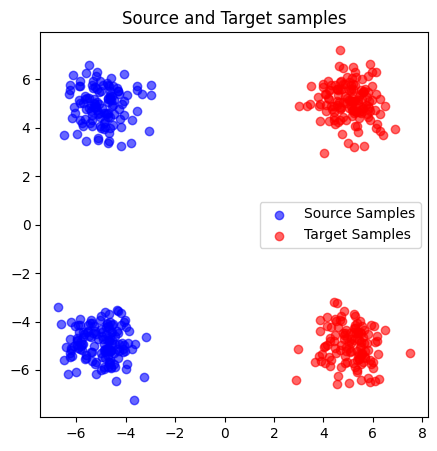

In [5]:
DrawSample.draw_samples_comparison(sample_source(256).cpu(), sample_target(256).cpu())

In [6]:
flow  = MLP()
batch = 1028

optimizer = torch.optim.Adam(flow.parameters(), lr = 1e-3)
loss_fn =  nn.MSELoss()

In [30]:
epochs = 4000
# des = sample_target(65536)
acc_loss = 0
for _ in range(epochs):
    # x_1 = des[torch.randint(0, des.size(0), (batch,))]  
    x_1 = sample_target(batch).to(device=device) 
    x_0 = sample_source(batch).to(device=device)
    # print(x_1.shape, x_0.shape)
    # x1 = x_1[greedy_coupling(x_0, x_1)]
    
    t = torch.rand(batch, 1)
    x_t = get_xt(x_0, x_1, t).to(device=device)
    u_t = x_1 - x_0
    
    v_pred = flow(x_t, t)
    loss = loss_fn(v_pred.flatten(), u_t.flatten())
    acc_loss += loss.item()
    # print(loss)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # acc_loss.append(loss.item())
    if ( (_ + 1) % 100 == 0):
        optimizer.zero_grad()
        optimizer.step()
        print(f"Epoch {_ + 1}, Loss: {acc_loss/100:.4f}")
        acc_loss = 0

Epoch 100, Loss: 8.9337
Epoch 200, Loss: 8.8935
Epoch 300, Loss: 8.8872
Epoch 400, Loss: 8.8600
Epoch 500, Loss: 8.8209
Epoch 600, Loss: 8.7450
Epoch 700, Loss: 8.7850
Epoch 800, Loss: 8.8044
Epoch 900, Loss: 8.6807
Epoch 1000, Loss: 8.7455
Epoch 1100, Loss: 8.6706
Epoch 1200, Loss: 8.6794
Epoch 1300, Loss: 8.7148
Epoch 1400, Loss: 8.6818
Epoch 1500, Loss: 8.6662
Epoch 1600, Loss: 8.5902
Epoch 1700, Loss: 8.5832
Epoch 1800, Loss: 8.5766
Epoch 1900, Loss: 8.6674
Epoch 2000, Loss: 8.5911
Epoch 2100, Loss: 8.5750
Epoch 2200, Loss: 8.6043
Epoch 2300, Loss: 8.6026
Epoch 2400, Loss: 8.5399
Epoch 2500, Loss: 8.5312
Epoch 2600, Loss: 8.4600
Epoch 2700, Loss: 8.4237
Epoch 2800, Loss: 8.4675
Epoch 2900, Loss: 8.4800
Epoch 3000, Loss: 8.4572
Epoch 3100, Loss: 8.4500
Epoch 3200, Loss: 8.5099
Epoch 3300, Loss: 8.4489
Epoch 3400, Loss: 8.3475
Epoch 3500, Loss: 8.4480
Epoch 3600, Loss: 8.3079
Epoch 3700, Loss: 8.3539
Epoch 3800, Loss: 8.3831
Epoch 3900, Loss: 8.2927
Epoch 4000, Loss: 8.3165


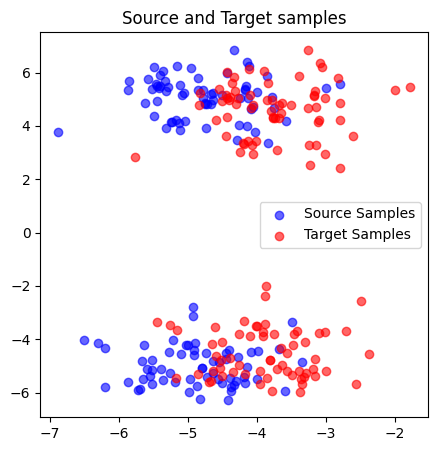

In [31]:
steps = 100
time_steps = torch.linspace(0, 1.0, steps + 1)

x = sample_source(128)
# print(x_0)

t = 0.0

results = []
# results.append(x)

flow.eval()
with torch.no_grad():
    for i in range(steps):
        x = flow.step(x, time_steps[i], time_steps[i + 1])
        results.append(x)

# results.append(sample_target(128))
# steps = 1.0/256
# results = solver.sample(x_0, step_size=1.0/steps,  time_grid=time_grid, return_intermediates=True)

# print("Sampled x_1:", results[:-1])

DrawSample.draw_samples_comparison(results[0].cpu(), results[-90].cpu())

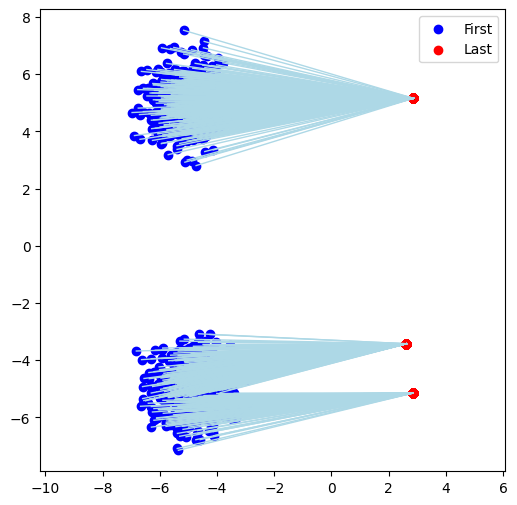

In [32]:
first = sample_source(1028)
last = sample_target(1028)
# mini_batch_coupling(first, last, mini_batch_size=32)
last = last[greedy_coupling(first, last)]

first = first.detach().cpu().numpy()
last = last.detach().cpu().numpy()

plt.figure(figsize=(6, 6))

# Vẽ điểm
plt.scatter(first[:, 0], first[:, 1], label='First', color='blue')
plt.scatter(last[:, 0], last[:, 1], label='Last', color='red')

# Vẽ đường nối màu xanh nhạt giữa các điểm tương ứng
for p1, p2 in zip(first, last):
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]],
             color='lightblue', linewidth=1)

plt.legend()
plt.axis('equal')
plt.show()

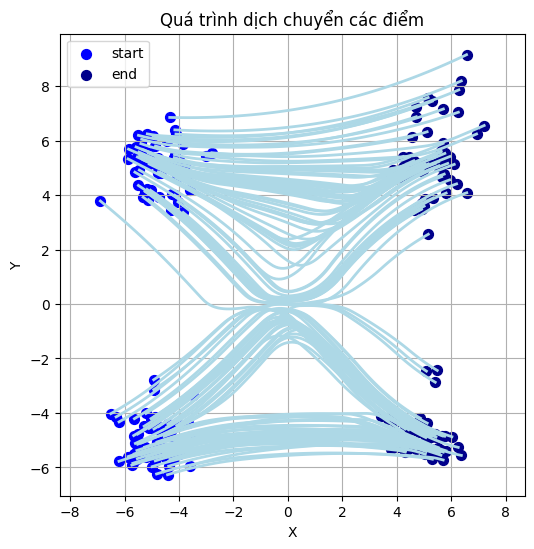

In [33]:
DrawFlow.draw_trajectory_from_results(results)

In [ ]:
results_cpu_list = [r.detach().cpu().numpy() for r in results]
print(results_cpu_list[0])
frames = []

for i, results_cpu in enumerate(results_cpu_list):
    fig, ax = plt.subplots(figsize=(5,5))
    
    ax.scatter(results_cpu[:,0], results_cpu[:,1], color='red', label=f'time step {i}')
    # ax.scatter(results_cpu[:,0], results_cpu[:,1], color='red', label=f'time step {i}')
    ax.legend()
    ax.set_title("ODE Sampling: Batch points over time")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.set_xlim([-10, 10])
    ax.set_ylim([-10, 10])
    
    # Lưu figure vào buffer
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    image = buf.reshape((h, w, 4))  # 4 kênh RGBA
    frames.append(image)
    plt.close(fig)

# Tạo GIF
imageio.mimsave('ode_sampling_batch.gif', frames, duration=0.01)

[[-4.3328667 -5.7070785]
 [-6.204636  -5.7777386]
 [-4.3795967 -5.9597297]
 [-2.7938757  5.557334 ]
 [-4.4209437 -6.2714567]
 [-5.339121   5.6788163]
 [-5.4906917  4.3543005]
 [-4.152538   6.3963223]
 [-5.121826   3.8357127]
 [-5.2795386 -4.4891396]
 [-3.781109   5.0980835]
 [-4.6385994 -5.271919 ]
 [-4.761761   4.818841 ]
 [-4.340549   6.8530955]
 [-5.4020543  5.508243 ]
 [-6.2016535 -4.3305526]
 [-5.0281124 -4.2077475]
 [-4.7827997  5.346935 ]
 [-3.9880345 -4.448457 ]
 [-4.640813   5.2375426]
 [-4.675334   5.195609 ]
 [-5.449793   5.482153 ]
 [-3.6844578 -4.367764 ]
 [-4.864227   5.8019013]
 [-4.0832314 -4.4639306]
 [-4.5071654 -5.63866  ]
 [-3.8583732  5.878292 ]
 [-4.7599444  4.8491597]
 [-4.088502   4.6271944]
 [-4.6364913  4.965344 ]
 [-4.71998   -5.403551 ]
 [-5.577477   5.7687163]
 [-4.870727  -5.761809 ]
 [-4.929429  -2.7831514]
 [-4.6347766 -4.809185 ]
 [-5.3872185 -5.107295 ]
 [-5.1641545  6.2491264]
 [-4.433721   5.97012  ]
 [-5.4710374  5.580248 ]
 [-5.045284   4.177459 ]
